In [15]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATH = "./aca-butterflies"
NUM_CLASSES = 75
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_EPOCHS = 100
PATIENCE = 7

# from our dataset, calculated at 0_EDA.ipynb file
RGB_MEAN = [0.4790, 0.4646, 0.3369]
RGB_STD = [0.2560, 0.2462, 0.2558]

# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [ ]:
from dataset_utilsCNN import ButterflyDataset

In [3]:
def build_transforms(mean, std, image_size=IMAGE_SIZE):
    train = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    
    return train, val

In [ ]:
train_transform, val_transform = build_transforms(RGB_MEAN, RGB_STD)

img_dir = os.path.join(PATH, "train")
df = pd.read_csv(os.path.join(PATH, "train.csv"))

df_train, df_val = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)

all_classes   = sorted(df["label"].unique())
class_to_idx  = {cls: idx for idx, cls in enumerate(all_classes)}

train_dataset = ButterflyDataset(df_train, img_dir, train_transform, class_to_idx)
val_dataset   = ButterflyDataset(df_val, img_dir, val_transform, class_to_idx)

# AJUSTE PARA VELOCIDADE E MPS:
train_loader = data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,           # Testar com 4 ou 8
    pin_memory=False,        # Manter False para MPS
    persistent_workers=True,  # Ganho de tempo entre épocas
    prefetch_factor=2        # Antecipa o carregamento
)

val_loader = data.DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=False
)

print(len(df_train))
print(len(df_val))

4159
1040


In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device, run_name="experiment"):
    counter_early_stopper = 0
    best_weights = None
    best_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, *_ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"Epoch {epoch:3d}/{num_epochs} | Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}")

        if vl_loss < best_loss - 1e-4:
            best_loss = vl_loss
            best_weights = copy.deepcopy(model.state_dict())
            counter_early_stopper = 0
        else:
            counter_early_stopper += 1
            if counter_early_stopper >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    elapsed_min = (time.time() - t0) / 60
    print(f"Training complete in {elapsed_min:.1f} minutes")
    model.load_state_dict(best_weights)
    return model, history, elapsed_min

In [7]:
def compute_metrics(labels, preds, name=""):
    acc = accuracy_score(labels, preds)
    f1_mac = f1_score(labels, preds, average="macro",  zero_division=0)
    f1_wei = f1_score(labels, preds, average="weighted", zero_division=0)

    print(f"{name}->Accuracy : {acc:.4f}")
    print(f"{name}->F1 (macro) : {f1_mac:.4f}")
    print(f"{name}->F1(weighted) : {f1_wei:.4f}")
    return {"accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_wei}

def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()
    
def plot_confusion_matrix(labels, preds, idx_to_class, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)

    errors_per_class = cm.sum(axis=1) - cm.diagonal()
    top25_idx = np.argsort(errors_per_class)[-25:][::-1]

    cm_top25     = cm[np.ix_(top25_idx, top25_idx)]
    class_names  = [idx_to_class[i] for i in top25_idx]

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm_top25, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.4, cbar_kws={"shrink": 0.7})
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_per_class_accuracy(labels, preds, idx_to_class):
    cm = confusion_matrix(labels, preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    sorted_idx   = np.argsort(per_class_acc)
    sorted_acc   = per_class_acc[sorted_idx]
    sorted_names = [idx_to_class[i] for i in sorted_idx]

    fig, ax = plt.subplots(figsize=(10, 18))
    colors = ["tomato" if a < 0.5 else "steelblue" for a in sorted_acc]
    ax.barh(sorted_names, sorted_acc, color=colors, edgecolor="white")
    ax.set_xlabel("Per-class Accuracy")
    ax.set_title("Per-class Accuracy")
    ax.set_xlim(0, 1.0)
    plt.tight_layout()
    plt.show()


In [ ]:
class ModernLeNet(nn.Module):
    def __init__(self, input_channels=3, num_classes=NUM_CLASSES):
        super(ModernLeNet, self).__init__()
        
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        
        # Ajustado para 224x224: 64 canais * 56 * 56 pixels
        self.fc1 = nn.Linear(64 * 56 * 56, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Cada F.max_pool2d com kernel 2 reduz a dimensão para metade
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2) # 224 -> 112
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2) # 112 -> 56
        
        x = x.view(x.size(0), -1) # Flatten: [Batch, 64*56*56]
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [10]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            # Conv 1: Captura bordas e blobs [cite: 537]
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv 2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv 3, 4 e 5: Extração de texturas e partes de objetos [cite: 538, 539]
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes), # Camada final para as 75 classes [cite: 542]
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [11]:
class VGG16(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(VGG16, self).__init__()
        # Configuração clássica de blocos VGG [cite: 588]
        self.features = self._make_layers([
            64, 64, 'M', 
            128, 128, 'M', 
            256, 256, 256, 'M', 
            512, 512, 512, 'M', 
            512, 512, 512, 'M'
        ])
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for v in cfg:
            if v == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)] # Redução de carga computacional [cite: 339]
            else:
                conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
                # Incluímos Batch Norm conforme sugerido para redes profundas [cite: 801]
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                in_channels = v
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [12]:
# Instanciar os modelos
# Nota: Certifica-te de que renomeaste a classe CNN_B para ModernLeNet
model_modernLeNet = ModernLeNet(num_classes=75)
model_alex = AlexNet(num_classes=75)
model_vgg = VGG16(num_classes=75)

def print_params(name, model):
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{name} — Total de parâmetros: {total_params:,}")

# Executar a contagem para cada uma
print_params("ModernLeNet", model_modernLeNet)
print_params("AlexNet", model_alex)
print_params("VGG16", model_vgg)

ModernLeNet — Total de parâmetros: 8,447,179
AlexNet — Total de parâmetros: 58,588,619
VGG16 — Total de parâmetros: 134,576,267


In [13]:
def build_optimizer(name, params, lr, weight_decay=1e-4):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == "rmsprop":
        # RMSprop com momentum conforme a tua definição original
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay, momentum=0.9)

def build_criterion(name):
    if name == "cross_entropy":
        # Cross Entropy com label smoothing para melhor generalização
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif name == "multi_margin":
        # Multi Margin Loss (útil para classificação com margem de erro)
        return nn.MultiMarginLoss(margin=1.0)
    
# Definição das 4 combinações para cada uma das 3 arquiteturas
experiments = [
    # --- Experiências com CNN_B (Baseline Modular) ---
    ("cnn_b_cel_adam",    lambda: ModernLeNet(), "cross_entropy", "adam",    1e-3),
    ("cnn_b_cel_rmsprop", lambda: ModernLeNet(), "cross_entropy", "rmsprop", 1e-3),
    ("cnn_b_mml_adam",    lambda: ModernLeNet(), "multi_margin",  "adam",    1e-3),
    ("cnn_b_mml_rmsprop", lambda: ModernLeNet(), "multi_margin",  "rmsprop", 1e-3),

    # --- Experiências com AlexNet (Aprendizagem Hierárquica) ---
    ("alexnet_cel_adam",    lambda: AlexNet(), "cross_entropy", "adam",    1e-4),
    ("alexnet_cel_rmsprop", lambda: AlexNet(), "cross_entropy", "rmsprop", 1e-4),
    ("alexnet_mml_adam",    lambda: AlexNet(), "multi_margin",  "adam",    1e-4),
    ("alexnet_mml_rmsprop", lambda: AlexNet(), "multi_margin",  "rmsprop", 1e-4),

    # --- Experiências com VGG16 (Filtros 3x3 Profundos) ---
    ("vgg16_cel_adam",    lambda: VGG16(), "cross_entropy", "adam",    1e-4),
    ("vgg16_cel_rmsprop", lambda: VGG16(), "cross_entropy", "rmsprop", 1e-4),
    ("vgg16_mml_adam",    lambda: VGG16(), "multi_margin",  "adam",    1e-4),
    ("vgg16_mml_rmsprop", lambda: VGG16(), "multi_margin",  "rmsprop", 1e-4),
]

In [14]:
results_summary = []
trained_models  = {}
all_histories   = {}
all_times       = {}

for run_name, model_fn, loss_name, optim_name, lr in experiments:
    print(f"\n{'='*60}")
    print(f"Run: {run_name}")
    print(f"Loss: {loss_name} | Optimizer: {optim_name} | LR: {lr}")
    print(f"{'='*60}")

    run_device = torch.device("cpu") if loss_name == "multi_margin" else device

    model     = model_fn().to(run_device)
    criterion = build_criterion(loss_name)
    optimizer = build_optimizer(optim_name, model.parameters(), lr)

    model, history, elapsed = train_model(
        model, train_loader, val_loader,
        criterion, optimizer,
        device=run_device,
        run_name=run_name
    )

    _, _, labels, preds = evaluate(model, val_loader, criterion, run_device)
    metrics = compute_metrics(labels, preds, name=run_name)

    results_summary.append({
        "run":       run_name,
        "loss":      loss_name,
        "optimizer": optim_name,
        "lr":        lr,
        "time_min":  round(elapsed, 2),
        **metrics
    })

    trained_models[run_name] = model
    all_histories[run_name]  = history
    all_times[run_name]      = elapsed

    plot_history(history, title=run_name)


Run: cnn_b_cel_adam
Loss: cross_entropy | Optimizer: adam | LR: 0.001


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Traceback (most recent call last):
  File "<string>", line 1, in <module>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 120, in spawn_main
  File "<string>", line 1, in <module>
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 120, in spawn_main
    exitcode = _main(fd, parent_sentinel)
    exitcode = _main(fd, parent_sentinel)
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^^^  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 130, in _main

  File "/Library/Frameworks/Python.framework/Versions/

RuntimeError: DataLoader worker (pid(s) 21745, 21746) exited unexpectedly

In [14]:
df_results = pd.DataFrame(results_summary).sort_values("f1_macro", ascending=False).reset_index(drop=True)
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results.to_string(index=False))

           run          loss optimizer     lr  time_min  accuracy  f1_macro  f1_weighted
 cnn_b_cel_sgd cross_entropy       sgd 0.0100    7.6500    0.6510    0.6343       0.6349
 cnn_b_mml_sgd  multi_margin       sgd 0.0100   22.0900    0.5865    0.5778       0.5779
cnn_b_cel_adam cross_entropy      adam 0.0010   13.9400    0.5202    0.4745       0.4782
cnn_b_mml_adam  multi_margin      adam 0.0010   16.0700    0.4885    0.4545       0.4576


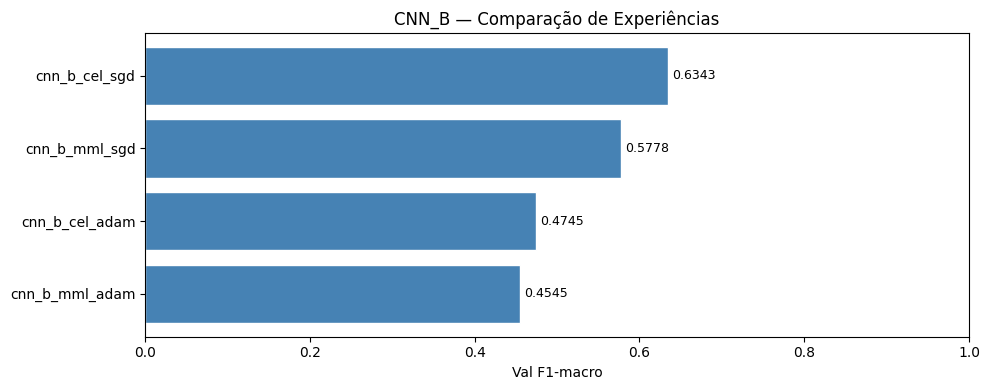

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_results["run"][::-1], df_results["f1_macro"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Val F1-macro")
ax.set_title("CNN_B — Comparação de Experiências")
ax.set_xlim(0, 1.0)
for bar, val in zip(bars, df_results["f1_macro"][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
best_run   = df_results.iloc[0]["run"]
best_model = trained_models[best_run]
print(f"Melhor modelo: {best_run}\n")

_, _, labels, preds = evaluate(best_model, val_loader, build_criterion(df_results.iloc[0]["loss"]), device)

print(classification_report(labels, preds, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)], zero_division=0))

Melhor modelo: cnn_b_cel_sgd

                           precision    recall  f1-score   support

                   ADONIS       1.00      0.79      0.88        14
AFRICAN GIANT SWALLOWTAIL       0.73      0.67      0.70        12
           AMERICAN SNOOT       0.31      0.67      0.42        12
                    AN 88       0.87      0.93      0.90        14
                  APPOLLO       0.77      0.71      0.74        14
                    ATALA       0.67      0.75      0.71        16
 BANDED ORANGE HELICONIAN       0.75      0.80      0.77        15
           BANDED PEACOCK       0.75      0.92      0.83        13
            BECKERS WHITE       0.33      0.08      0.12        13
         BLACK HAIRSTREAK       1.00      0.79      0.88        14
              BLUE MORPHO       0.60      0.25      0.35        12
        BLUE SPOTTED CROW       0.40      0.29      0.33        14
           BROWN SIPROETA       1.00      0.62      0.77        16
            CABBAGE WHITE      

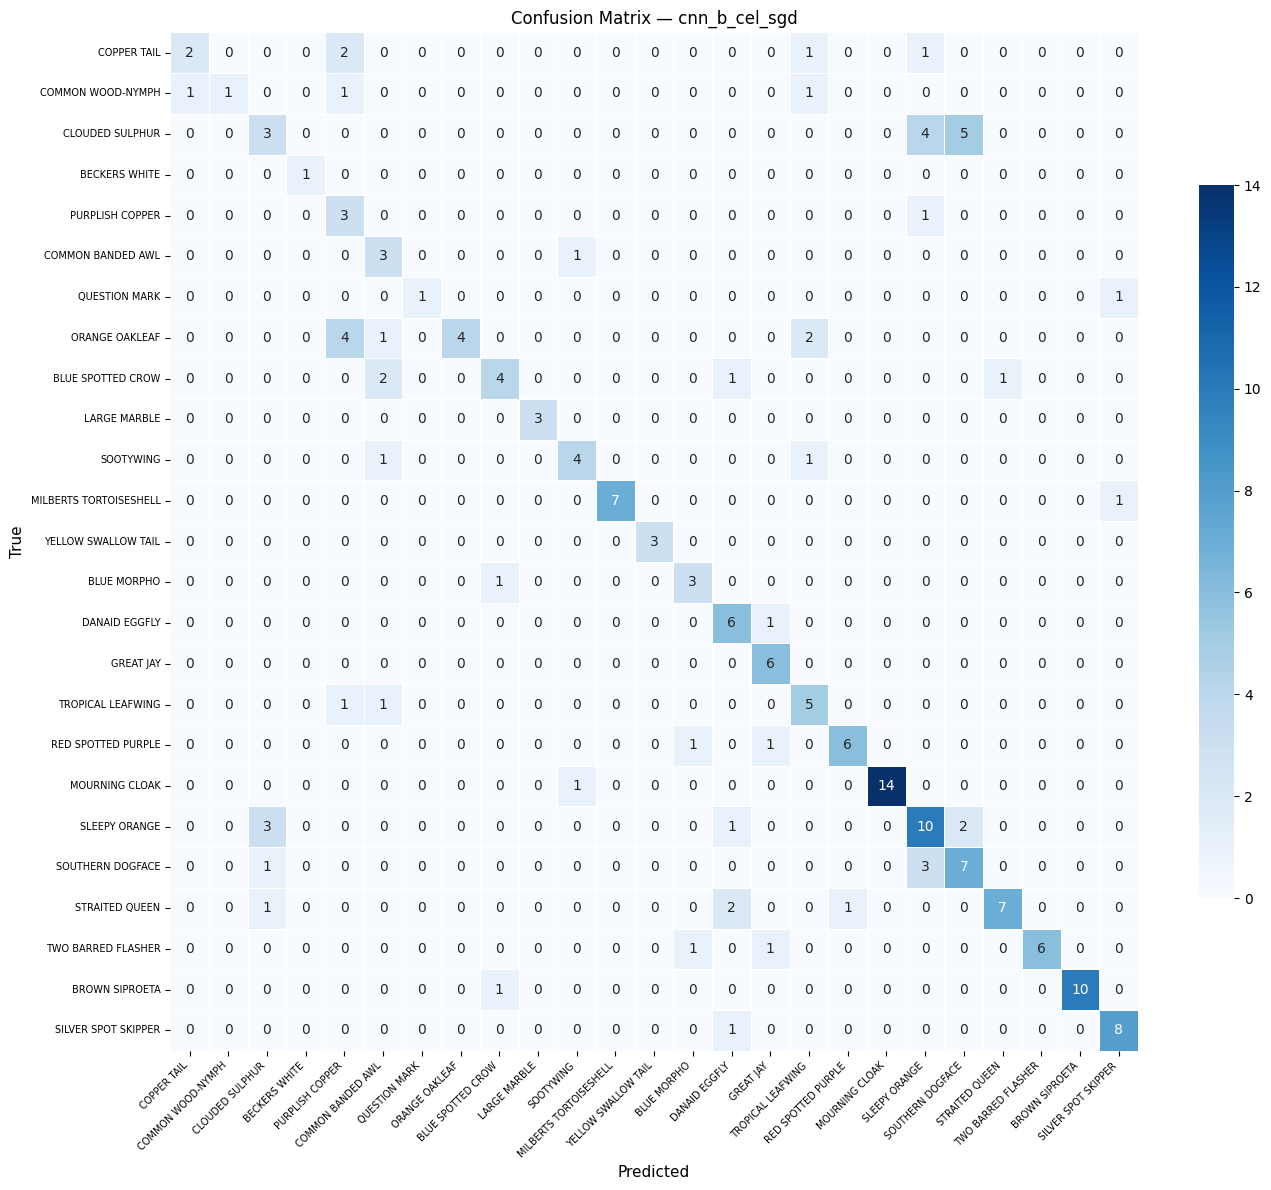

In [17]:
plot_confusion_matrix(labels, preds, idx_to_class, title=f"Confusion Matrix — {best_run}")

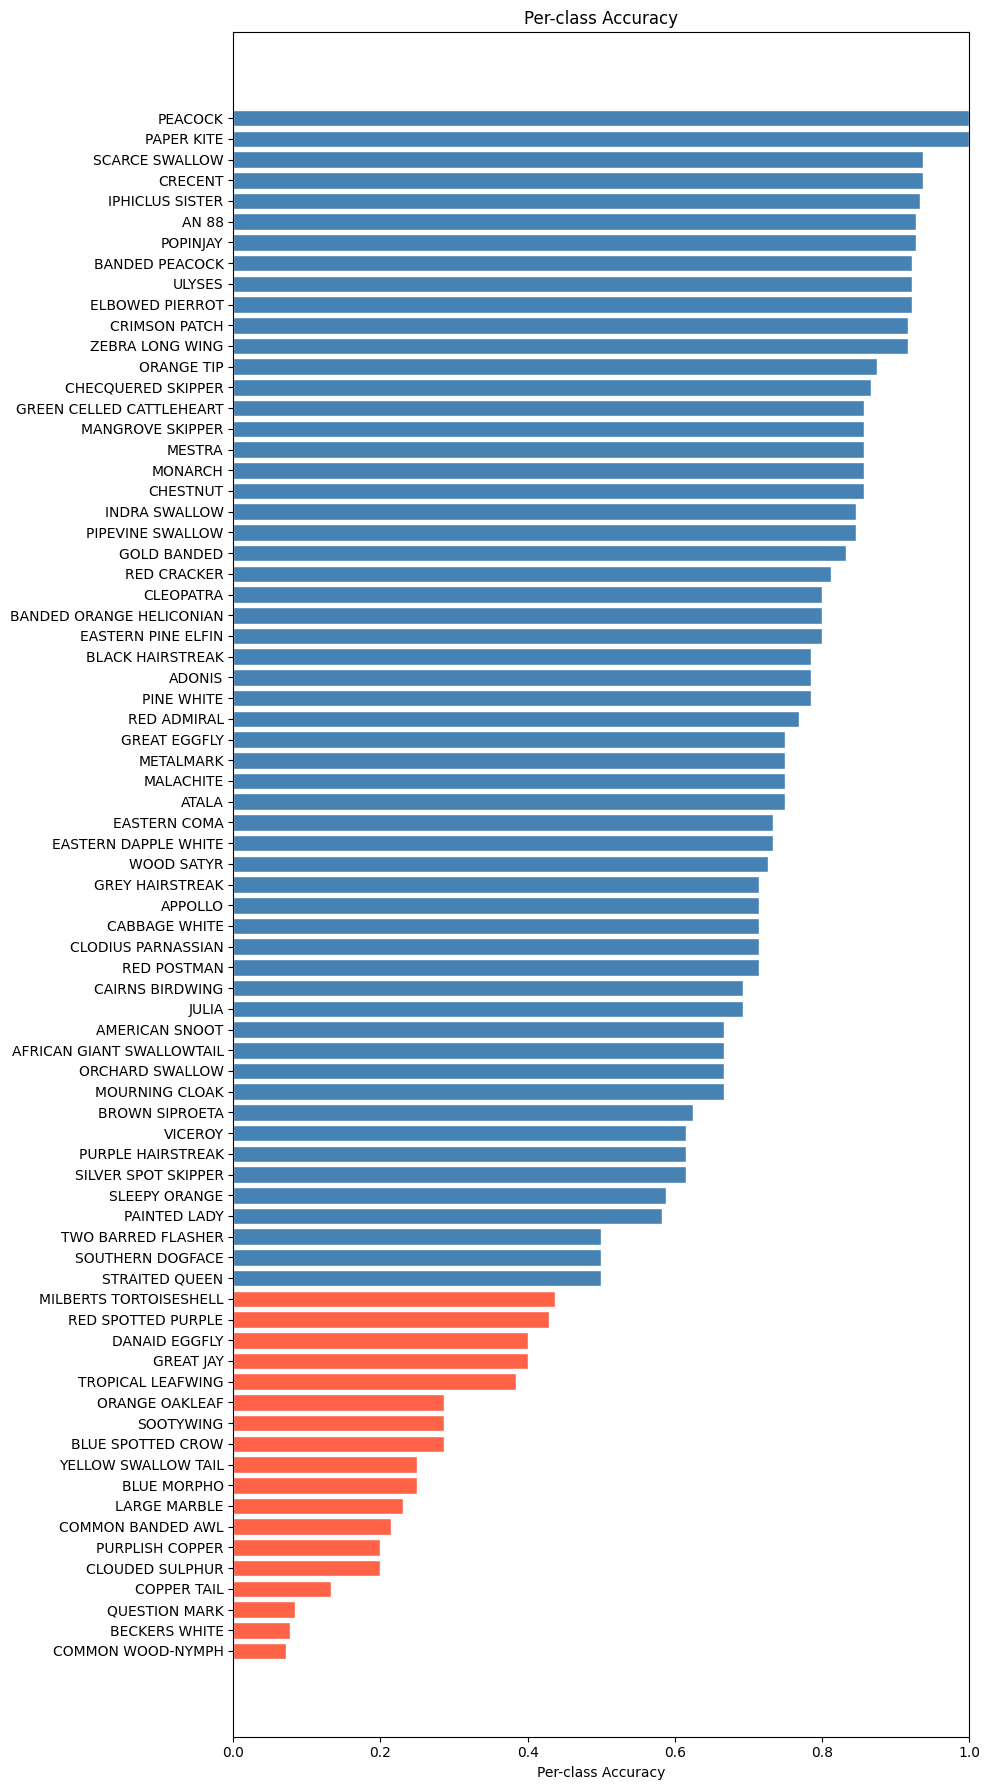

In [18]:
plot_per_class_accuracy(labels, preds, idx_to_class)